In [1]:
import numpy as np
import pandas as pd
from scipy import integrate
import matplotlib.pyplot  as plt

In [2]:
# Funzione per potenziale a onda quadra
def Vin_square(t):
    """
    Funzione per potenziale ad onda quadra
    
    return: 
        +1 per int(t) pari
        -1 per int(t) dispari
    """

    if np.isscalar(t) :
        if int(t)%2 == 0:
            return 1
        else:
            return -1
    else:
        
        vin = np.ones(len(t))
        odd_mask = t.astype(int) %2 != 0
        vin[odd_mask] = -1
        return vin

In [3]:
# Funzione per potenziale a dente di sega 
def Vin_st(t):
    """
    Funzione per potenziale a dente di sega
    
    return:    (t/2 - int(t/2) -0.5)^2
    """

    
    if np.isscalar(t) :
        return (t/2-int(t/2)-0.5)**2
    else:
        return (t/2-(t/2).astype(int)-0.5)**2

In [4]:
############################################################################
#      Funzione per Equazione Differenziale filtro RC passa basso          #
############################################################################
def vout_eqn(vout, t, rc, vinf ):
    """
    Funzione per Equazione Differenziale filtro RC passa basso
    
    Implementa l'equazione:

      dVout/dt = (Vin - Vout)/RC 
    Parametri:
      vout : potenziale Vout
      t    : tempo
      rc   : costante RC del circuito 
      vinf : funzione per calcolare il potenziali di ingresso Vin(t)
    
    Output:
      return  (vinf(t) - vout) / rc
    """
    dvoutdt = (vinf(t) - vout) / rc
    return dvoutdt

In [6]:
# Costanti RC circuito 
rc1   = 1
rc05  = 0.5
rc01  = 0.1

# Condizione iniziale V(0) = 0 
vo0 = 0

# Array per i tempi da 0 a 10 s
time = np.arange(0, 10, 0.01)

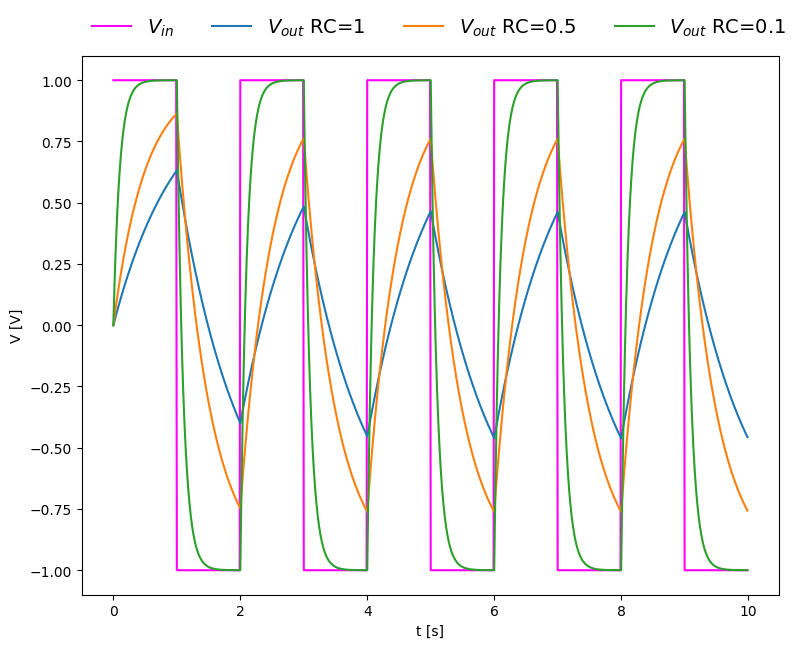

In [7]:
#--------------------------------------------------------------------------------#
#                Vin(t) = Onda Quadra                                            #
#--------------------------------------------------------------------------------#

# Calcolo potenziale Vout con metodo scipy.integrate.odeint 
vout_sq_rc1   = integrate.odeint(vout_eqn, y0=vo0, t=time, args=(rc1,   Vin_square))
vout_sq_rc05  = integrate.odeint(vout_eqn, y0=vo0, t=time, args=(rc05,  Vin_square))
vout_sq_rc01  = integrate.odeint(vout_eqn, y0=vo0, t=time, args=(rc01, Vin_square))

# Grafico soluzioni 
plt.subplots(figsize=(9,7))
#plt.title(r'$V_{in}$ Onda Quadra', fontsize=16,     color='magenta')
plt.plot(time, Vin_square(time),  label='$V_{in}$', color='magenta')
plt.plot(time, vout_sq_rc1,   label='$V_{out}$ RC=1'  )
plt.plot(time, vout_sq_rc05,  label='$V_{out}$ RC=0.5') 
plt.plot(time, vout_sq_rc01,  label='$V_{out}$ RC=0.1')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('t [s]')
plt.ylabel('V [V]')
plt.legend( fontsize=14, ncol=4, bbox_to_anchor=(-0.01, 1.0, 1.0, 0.25), loc='lower left', framealpha=0  )
plt.show()

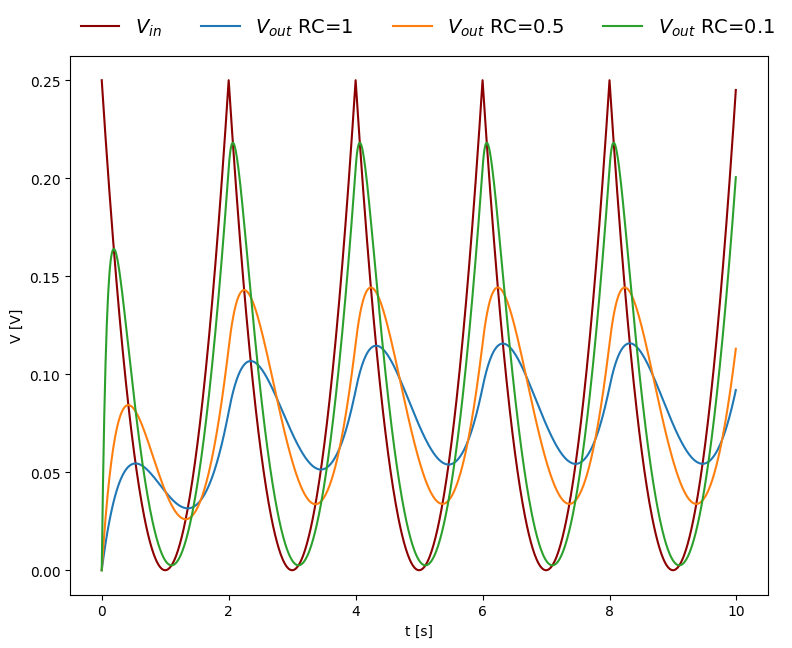

In [8]:
#--------------------------------------------------------------------------------#
#                Vin(t) = Dente di Sega                                          #
#--------------------------------------------------------------------------------#

# Calcolo potenziale Vout con metodo scipy.integrate.odeint 
vout_st_rc1   = integrate.odeint(vout_eqn, y0=vo0, t=time, args=(rc1,   Vin_st))
vout_st_rc05  = integrate.odeint(vout_eqn, y0=vo0, t=time, args=(rc05,  Vin_st))
vout_st_rc01  = integrate.odeint(vout_eqn, y0=vo0, t=time, args=(rc01,  Vin_st))

# Grafico soluzioni 
plt.subplots(figsize=(9,7))
#plt.title(r'$V_{in}$ Dente di Sega', fontsize=16, color='darkred')
plt.plot(time, Vin_st(time),  label='$V_{in}$',  color='darkred')
plt.plot(time, vout_st_rc1,   label='$V_{out}$ RC=1'  )
plt.plot(time, vout_st_rc05,  label='$V_{out}$ RC=0.5')
plt.plot(time, vout_st_rc01,  label='$V_{out}$ RC=0.1')
plt.legend(loc='upper right', fontsize=14)
plt.xlabel('t [s]')
plt.ylabel('V [V]')
plt.legend( fontsize=14, ncol=4, bbox_to_anchor=(-0.01, 1.0, 1.0, 0.25), loc='lower left', framealpha=0  )
plt.show()

All'aumentare del prodotto **RC** la tensione in uscita diminuisce in quanto l'impedenza del circuito:
$$ z_{pb}= \sqrt{R^2 + \left (\frac{1}{\omega C}\right )^2} $$

è proporzionale a $ RC $.